# PCam Data Pipeline Exploration (Phase 1)

**Status: Data pipeline implemented — model training pending.**

This notebook demonstrates the PatchCamelyon (PCam) data pipeline: loading,
verifying, and visualizing the dataset. It does **not** train a model.

All logic lives in `src/` — this notebook only calls it, so the pipeline can
be reused identically from scripts, other notebooks, or CI.

Run `python scripts/download_data.py` from the repository root before
running this notebook, if you haven't already.

In [1]:
# If running in Google Colab, uncomment and run this cell first:
# !git clone https://github.com/<your-username>/PathologyAI-Explorer.git
# %cd PathologyAI-Explorer
# !pip install -r requirements.txt -q
# !python scripts/download_data.py

In [2]:
import os
import sys
from pathlib import Path

# Ensure the repo root is on the path AND is the working directory, so that
# relative paths in configs/experiment.yaml (data/, results/) resolve
# correctly regardless of whether this notebook is launched from the repo
# root or from inside notebooks/ (Jupyter's default).
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

from src.utils import load_config, seed_everything, get_device
from src.data.dataset import build_datasets, build_dataloaders
from src.data.transforms import get_train_transforms, get_eval_transforms
from src.visualization.visualize import save_sample_grid

config = load_config("configs/experiment.yaml")
seed_everything(config["seed"])
device = get_device(config["device"]["prefer"])
print(f"Working directory: {Path.cwd()}")
print(f"Device: {device}")

CUDA requested but not available — falling back to CPU.
Working directory: /home/claude/PathologyAI-Explorer
Device: cpu


## Load datasets and inspect sizes / class balance

In [3]:
image_size = config["data"]["image_size"]

train_ds, valid_ds, test_ds = build_datasets(
    config,
    train_transform=get_train_transforms(image_size),
    eval_transform=get_eval_transforms(image_size),
)

print(f"Train: {len(train_ds):,} patches")
print(f"Valid: {len(valid_ds):,} patches")
print(f"Test:  {len(test_ds):,} patches")

Train: 500 patches
Valid: 200 patches
Test:  200 patches


In [4]:
import numpy as np

# Class balance check on a sample of each split (full-split scan is cheap
# too, but this keeps the notebook fast to re-run).
for name, ds in [("Train", train_ds), ("Valid", valid_ds), ("Test", test_ds)]:
    sample_n = min(2000, len(ds))
    ds._ensure_open()
    labels = np.array(ds._y_file["y"][:sample_n]).squeeze()
    n_pos = int(labels.sum())
    print(f"{name}: {n_pos}/{sample_n} positive ({100 * n_pos / sample_n:.1f}%)")

Train: 250/500 positive (50.0%)
Valid: 100/200 positive (50.0%)
Test: 100/200 positive (50.0%)


## Inspect a single example (tensor shape, label)

In [5]:
image, label = train_ds[0]
print(f"Transformed image tensor shape: {tuple(image.shape)}, dtype: {image.dtype}")
print(f"Label: {label}")

Transformed image tensor shape: (3, 96, 96), dtype: torch.float32
Label: 1


## Confirm the DataLoader works end-to-end

In [6]:
train_loader, valid_loader, test_loader = build_dataloaders(
    config,
    train_transform=get_train_transforms(image_size),
    eval_transform=get_eval_transforms(image_size),
)

batch_images, batch_labels = next(iter(train_loader))
print(f"Batch image shape: {tuple(batch_images.shape)}")
print(f"Batch label shape: {tuple(batch_labels.shape)}")
print(f"Example labels: {batch_labels[:10].tolist()}")

CUDA requested but not available — falling back to CPU.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:431: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:437: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch image shape: (64, 3, 96, 96)
Batch label shape: (64,)
Example labels: [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]


## Visualize a sample grid of patches

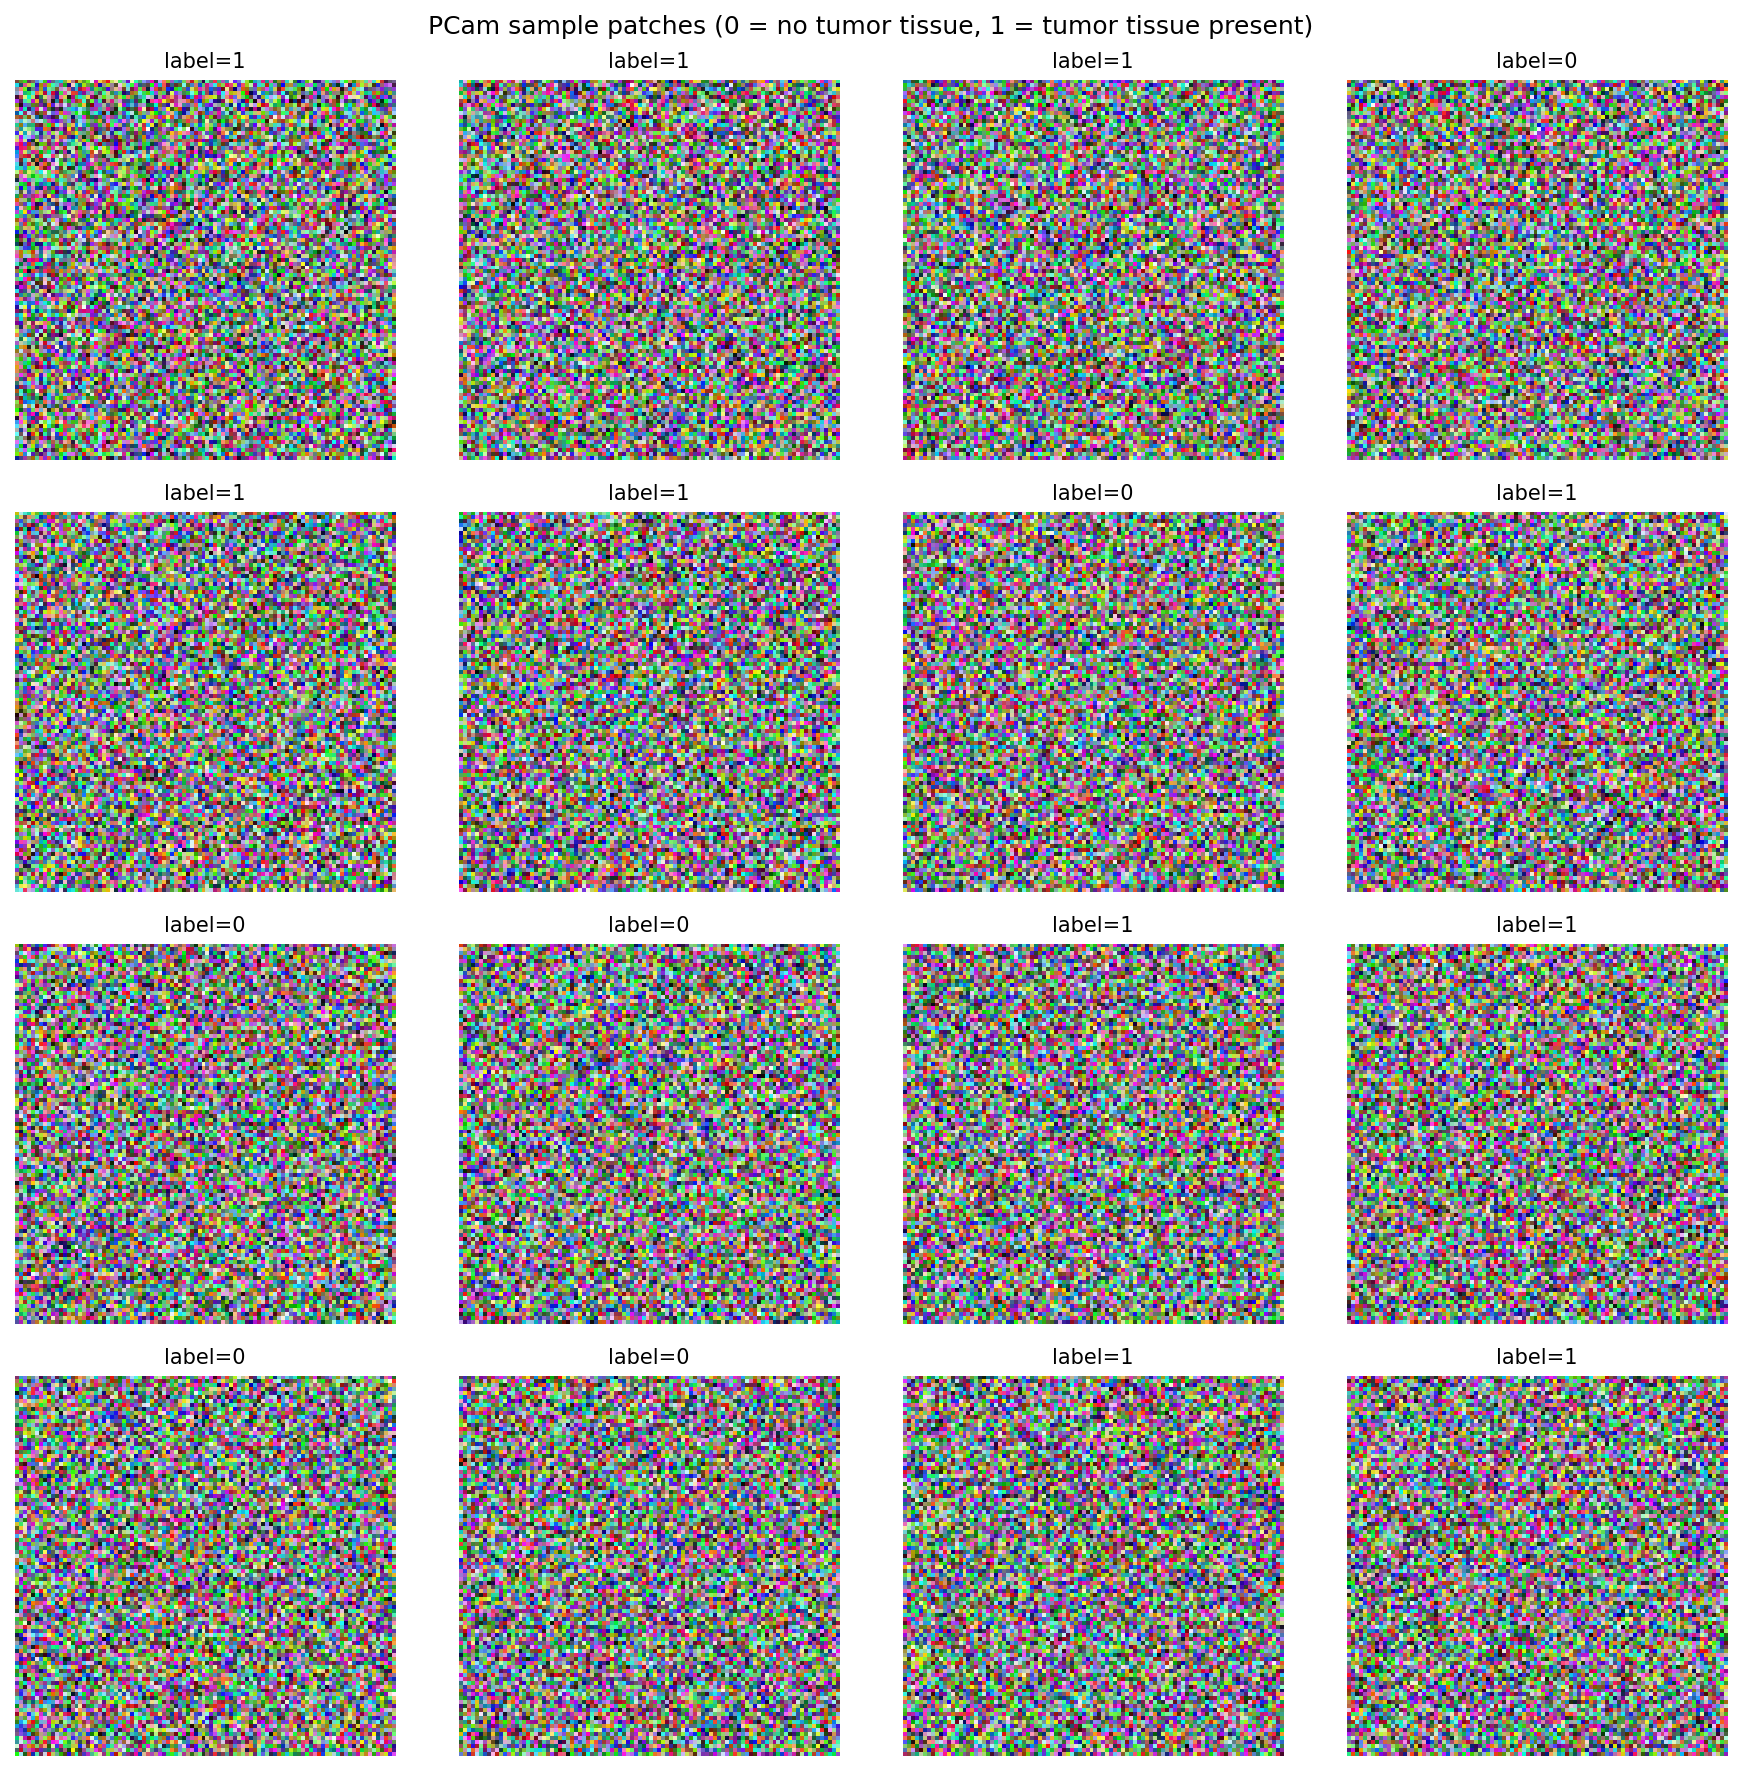

In [7]:
from IPython.display import Image as IPImage

fig_path = Path(config["results"]["figures_dir"]) / "sample_patches.png"
save_sample_grid(train_ds, fig_path, n_samples=16, seed=config["seed"])
IPImage(filename=str(fig_path))

## Summary

- PCam loads correctly through the full pipeline: HDF5 -> Dataset -> transform -> DataLoader.
- Class balance matches the documented 50/50 split.
- Tensor shapes are as expected for a 96x96 RGB input to a torchvision-style ResNet50.

**No model has been trained. No accuracy/F1/etc. numbers exist yet.**
The next phase adds ResNet50 transfer learning, training, and evaluation.